# Correlating fish observations with physical conditions in Øresund

A good approach is to interpolate the CTD profiles in space and depth, then assign each fish observation the nearest hydrographic conditions (temperature and salinity) and finally analyse relationships statistically.

Because the CTDs are discrete casts while fish observations are continuous along transects, the workflow is:

1. Read all CTD files (.cnv).
2. Extract cast latitude/longitude from each file header.
3. Combine all casts into one dataframe.
4. For every fish observation:
    * find nearby CTD casts,
    * interpolate temperature and salinity to the fish depth,
    * optionally weight by horizontal distance.
5. Produce a merged dataset.
6. Run analysis.

### 1.1 Read Seabird CTD files

##### Function to read SeaBird .cnv

In [42]:
import pandas as pd
import numpy as np
import glob
import re
import os

os.chdir('/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs')

def read_cnv(filename):

    with open(filename, 'r', encoding='latin1') as f:
        lines = f.readlines()

    # latitude
    lat_line = [l for l in lines if "NMEA Latitude" in l][0]
    lon_line = [l for l in lines if "NMEA Longitude" in l][0]

    lat_match = re.search(r'(\d+)\s+([\d.]+)\s+([NS])', lat_line)
    lon_match = re.search(r'(\d+)\s+([\d.]+)\s+([EW])', lon_line)

    lat_deg, lat_min, lat_dir = lat_match.groups()
    lon_deg, lon_min, lon_dir = lon_match.groups()

    lat = float(lat_deg) + float(lat_min)/60
    lon = float(lon_deg) + float(lon_min)/60

    if lat_dir == "S":
        lat *= -1
    if lon_dir == "W":
        lon *= -1

    # locate data start
    start = [i for i, l in enumerate(lines) if "*END*" in l][0] + 1

    data = pd.read_csv(
    filename,
    skiprows=start,
    sep=r"\s+",
    header=None,
    engine="python"
)

    data.columns = ["depth_m", "salinity", "temperature", "flag"]

    data["cast_lat"] = lat
    data["cast_lon"] = lon
    data["cast_file"] = filename

    return data

##### Read all casts

In [43]:
data_folder = '/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs'

files = glob.glob(data_folder + "/*.cnv")

print(f"Found {len(files)} files")
print(files[:5])

ctd = pd.concat([read_cnv(f) for f in files],
                ignore_index=True)

print(ctd.head())

Found 27 files
['/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs/2026-bio-494.cnv', '/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs/2026-bio-497.cnv', '/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs/2026-bio-480-10.cnv', '/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs/2026-bio-508.cnv', '/Users/Christian/Library/Mobile Documents/com~apple~CloudDocs/University/DTU/Applied Ocean Observation Technologies/Fish project/CTD + fish obs/2026-bio-482-5.cnv']
   depth_m  salinity  temperature  flag   cast_lat  cast_lon  \
0    1.592   11.7795      15.8334   0.0  55.832167   12.6865   
1    1.629   11.7803      15.83

### 1.2 Read fish observations

And create a representative depth by using average of min and max depth

In [44]:
import glob
import os
import pandas as pd

fish_files = glob.glob(data_folder + "/*.csv")

fish_list = []

for f in fish_files:

    df = pd.read_csv(f)

    df["source_file"] = os.path.basename(f)

    fish_list.append(df)

fish = pd.concat(
    fish_list,
    ignore_index=True
)

print("Number of fish files:", len(fish_files))
print("Total observations:", len(fish))

fish["depth_m"] = (
    fish["depth_min_m"] +
    fish["depth_max_m"]
) / 2

Number of fish files: 3
Total observations: 277


### 2 Link fish to CTD casts and interpolate CTD values to fish depth

In [45]:
from geopy.distance import geodesic

def nearest_casts(fish_row, cast_locations, n=3): #uses 3 nearest casts to interpolate temperature and salinity
    distances = []

    fish_pos = (fish_row.lat, fish_row.lon)

    for idx, row in cast_locations.iterrows():
        cast_pos = (row.cast_lat, row.cast_lon)
        d = geodesic(fish_pos, cast_pos).km
        distances.append(d)

    cast_locations = cast_locations.copy()
    cast_locations["distance_km"] = distances

    return cast_locations.sort_values("distance_km").head(n)


def interpolate_profile(profile, depth):

    temp = np.interp(
        depth,
        profile.depth_m,
        profile.temperature
    )

    sal = np.interp(
        depth,
        profile.depth_m,
        profile.salinity
    )

    return temp, sal


# define this OUTSIDE the function
cast_locations = (
    ctd[["cast_file", "cast_lat", "cast_lon"]]
    .drop_duplicates()
)

temps = []
sals = []

for _, fish_row in fish.iterrows():

    nearest = nearest_casts(fish_row, cast_locations, n=3) #uses 3 nearest casts to interpolate temperature and salinity

    t_list = []
    s_list = []
    weights = []

    for _, cast in nearest.iterrows():

        profile = ctd[ctd.cast_file == cast.cast_file]

        t, s = interpolate_profile(profile, fish_row.depth_m)

        weight = 1 / (cast.distance_km + 0.001) #weighs casts by relative distance to fish

        t_list.append(t)
        s_list.append(s)
        weights.append(weight)

    temps.append(np.average(t_list, weights=weights))
    sals.append(np.average(s_list, weights=weights))

fish["temperature"] = temps
fish["salinity"] = sals

### 3 Analysis

##### Mean physical conditions at fish depth

In [55]:
# print(fish.groupby("category")[["temperature","salinity"]].mean()) #individual vs school


summary = fish[["temperature", "salinity", "depth_m"]].agg(
    ["mean", "std", "min", "max", "median"]
)
print(summary)

# coefficient of variation
cv_temp = fish.temperature.std() / fish.temperature.mean() * 100
cv_sal = fish.salinity.std() / fish.salinity.mean() * 100
cv_depth = fish.depth_m.std() / fish.depth_m.mean() * 100

print(f"Temperature CV = {cv_temp:.1f}%")
print(f"Salinity CV = {cv_sal:.1f}%")
print(f"Depth CV = {cv_depth:.1f}%")

        temperature   salinity    depth_m
mean      14.327793  18.335320   8.908303
std        0.673860   2.281621   0.993878
min       11.558833  11.585981   5.000000
max       15.836099  25.533718  12.500000
median    14.389219  18.536087   9.000000
Temperature CV = 4.7%
Salinity CV = 12.4%
Depth CV = 11.2%


##### Fish depth distribution

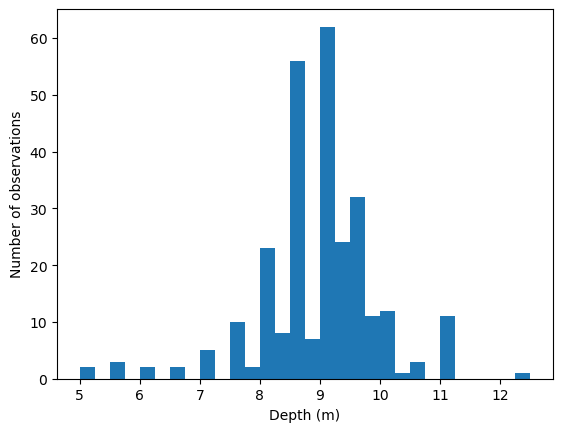

In [47]:
import matplotlib.pyplot as plt

plt.hist(fish["depth_m"], bins=30)
plt.xlabel("Depth (m)")
plt.ylabel("Number of observations")
plt.show()

##### Temperature and salinity distribution experienced by fish

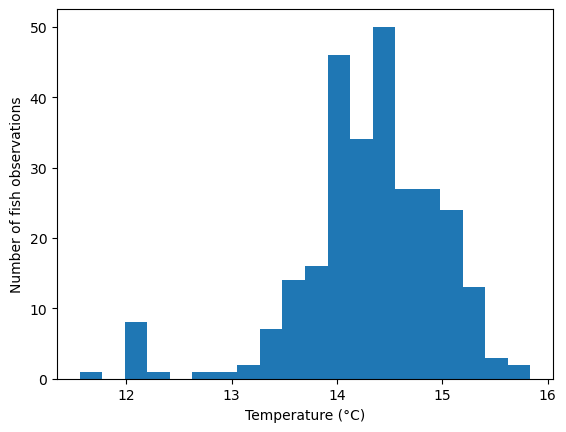

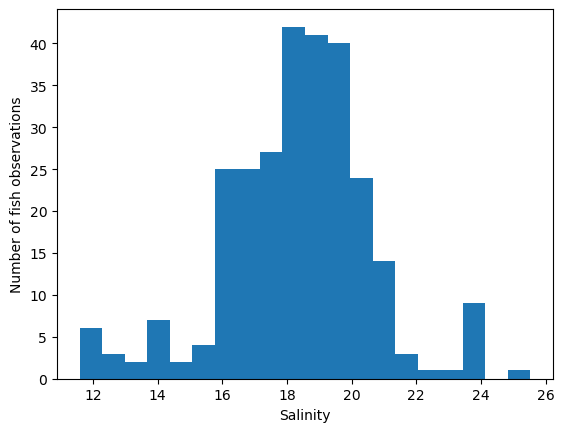

In [48]:
plt.hist(fish["temperature"], bins=20)
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of fish observations")
plt.show()

plt.hist(fish["salinity"], bins=20)
plt.xlabel("Salinity")
plt.ylabel("Number of fish observations")
plt.show()

In [49]:
fish[[
    "depth_m",
    "temperature",
    "salinity"
]].corr()

,depth_m,temperature,salinity
depth_m,1.000000,-0.831611,0.913649
temperature,-0.831611,1.000000,-0.936854
salinity,0.913649,-0.936854,1.000000


### 4 More analysis

##### 4.1 Calculate density

In [50]:
import gsw

ctd["density"] = gsw.rho(
    SA=ctd["salinity"],
    CT=ctd["temperature"],
    p=ctd["depth_m"]
)

##### 4.2 Identify pycnocline depth for each cast

In [51]:
# Sort each profile by depth:
ctd = ctd.sort_values(["cast_file", "depth_m"])

ctd["drho_dz"] = (
    ctd.groupby("cast_file")["density"]
    .diff()
    /
    ctd.groupby("cast_file")["depth_m"].diff()
)

pycnocline_depths = (
    ctd.loc[
        ctd.groupby("cast_file")["drho_dz"].idxmax(),
        ["cast_file", "depth_m"]
    ]
)

pycnocline_depths.columns = [
    "cast_file",
    "pycnocline_depth"
]


pycnocline_depths = []

for cast, profile in ctd.groupby("cast_file"):

    profile = profile.sort_values("depth_m")

    profile["drho_dz"] = (
        profile["density"].diff() /
        profile["depth_m"].diff()
    )

    # Ignore surface artefacts
    profile = profile[profile["depth_m"] > 3]

    idx = profile["drho_dz"].idxmax()

    pycnocline_depths.append({
        "cast_file": cast,
        "pycnocline_depth":
            profile.loc[idx, "depth_m"]
    })

pycnocline_depths = pd.DataFrame(pycnocline_depths)

# This defines the pycnocline as the depth of maximum density gradient.

##### 4.3 Assign pycnocline depth to each fish

In [52]:
fish_pycnocline = []

for _, fish_row in fish.iterrows():

    nearest = nearest_casts(
        fish_row,
        cast_locations,
        n=1
    )

    cast_name = nearest.iloc[0]["cast_file"]

    pyc_depth = pycnocline_depths.loc[
        pycnocline_depths["cast_file"] == cast_name,
        "pycnocline_depth"
    ].values[0]

    fish_pycnocline.append(pyc_depth)

fish["pycnocline_depth"] = fish_pycnocline

##### 4.4 Distance from fish to pycnocline

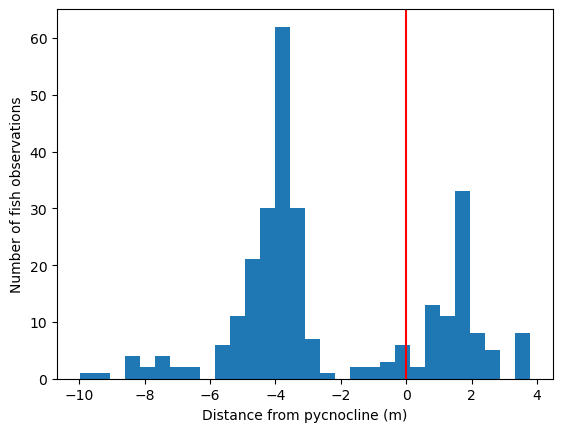

In [53]:
fish["distance_to_pycnocline"] = (
    fish["depth_m"] -
    fish["pycnocline_depth"]
)

fish["distance_to_pycnocline"].describe()

import matplotlib.pyplot as plt

plt.hist(
    fish["distance_to_pycnocline"],
    bins=30
)

plt.axvline(0, color="red")

plt.xlabel("Distance from pycnocline (m)")
plt.ylabel("Number of fish observations")
plt.show()

##### Pearson correlation with pycnocline

0.04334512612057044 0.4724600169127067


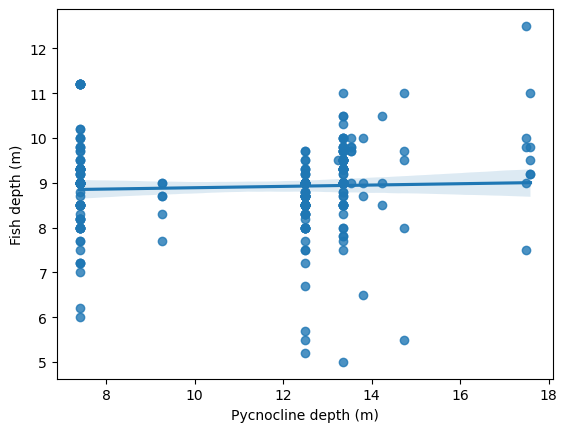

In [54]:
from scipy.stats import pearsonr

r, p = pearsonr(
    fish["depth_m"],
    fish["pycnocline_depth"]
)

print(r, p)

import seaborn as sns

sns.regplot(
    data=fish,
    x="pycnocline_depth",
    y="depth_m"
)

plt.xlabel("Pycnocline depth (m)")
plt.ylabel("Fish depth (m)")
plt.show()